# PBMC 3k

Public 10x PBMC 3k, raw UMIs. Default scFair HVG, then PCA / Leiden / UMAP.
Leave the gene axis intact; `sc.tl.pca` reads `var["highly_variable"]`.

Auto estimates a base `k` and appends a short same-rank tail. It builds
extra neighbor graphs, so the call is slower than `n_top_genes=2000`.


In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import scanpy as sc
import scfair as scf

sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, frameon=False)
sc.settings.datasetdir = Path(tempfile.gettempdir()) / "scanpy_data"

print("scfair", scf.__version__)


scfair 0.10.0


## Load and QC

`sc.datasets.pbmc3k()` is raw UMI counts, no labels. Filter before HVG;
do not normalize yet.


In [2]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
adata = adata[adata.obs["n_genes_by_counts"] < 4000].copy()
adata


AnnData object with n_obs × n_vars = 2698 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

## HVG


In [3]:
scf.pp.highly_variable_genes(adata, progress=False)

h = adata.uns["scfair"]["hvg"]
print(h["n_highly_variable_final"], "genes")
print(h.get("auto_message"))
adata.var.loc[
    adata.var["highly_variable"],
    ["highly_variable_rank", "scfair_score"],
].sort_values("highly_variable_rank").head()


2200 genes
Base list size set to 2000: density confidence was low, so a classical ~2000 base is safer. Pass n_top_genes=... to override.


,highly_variable_rank,scfair_score
index,,
PPBP,0.0,11.172256
S100A9,1.0,7.993364
LYZ,2.0,7.972817
IGLL5,3.0,7.964822
GNLY,4.0,7.493396


`scfair_score` is the flavor statistic (`variances_norm` here), not a
probability. Only the rank order is used.

## Cluster


In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.pca(adata, svd_solver="arpack", random_state=0)
sc.pp.neighbors(adata, random_state=0)
sc.tl.leiden(adata, random_state=0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata, random_state=0)

adata.obs["leiden"].value_counts()


leiden
2    587
6    543
1    357
0    352
7    350
3    172
5    161
4    155
8     12
9      9
Name: count, dtype: int64

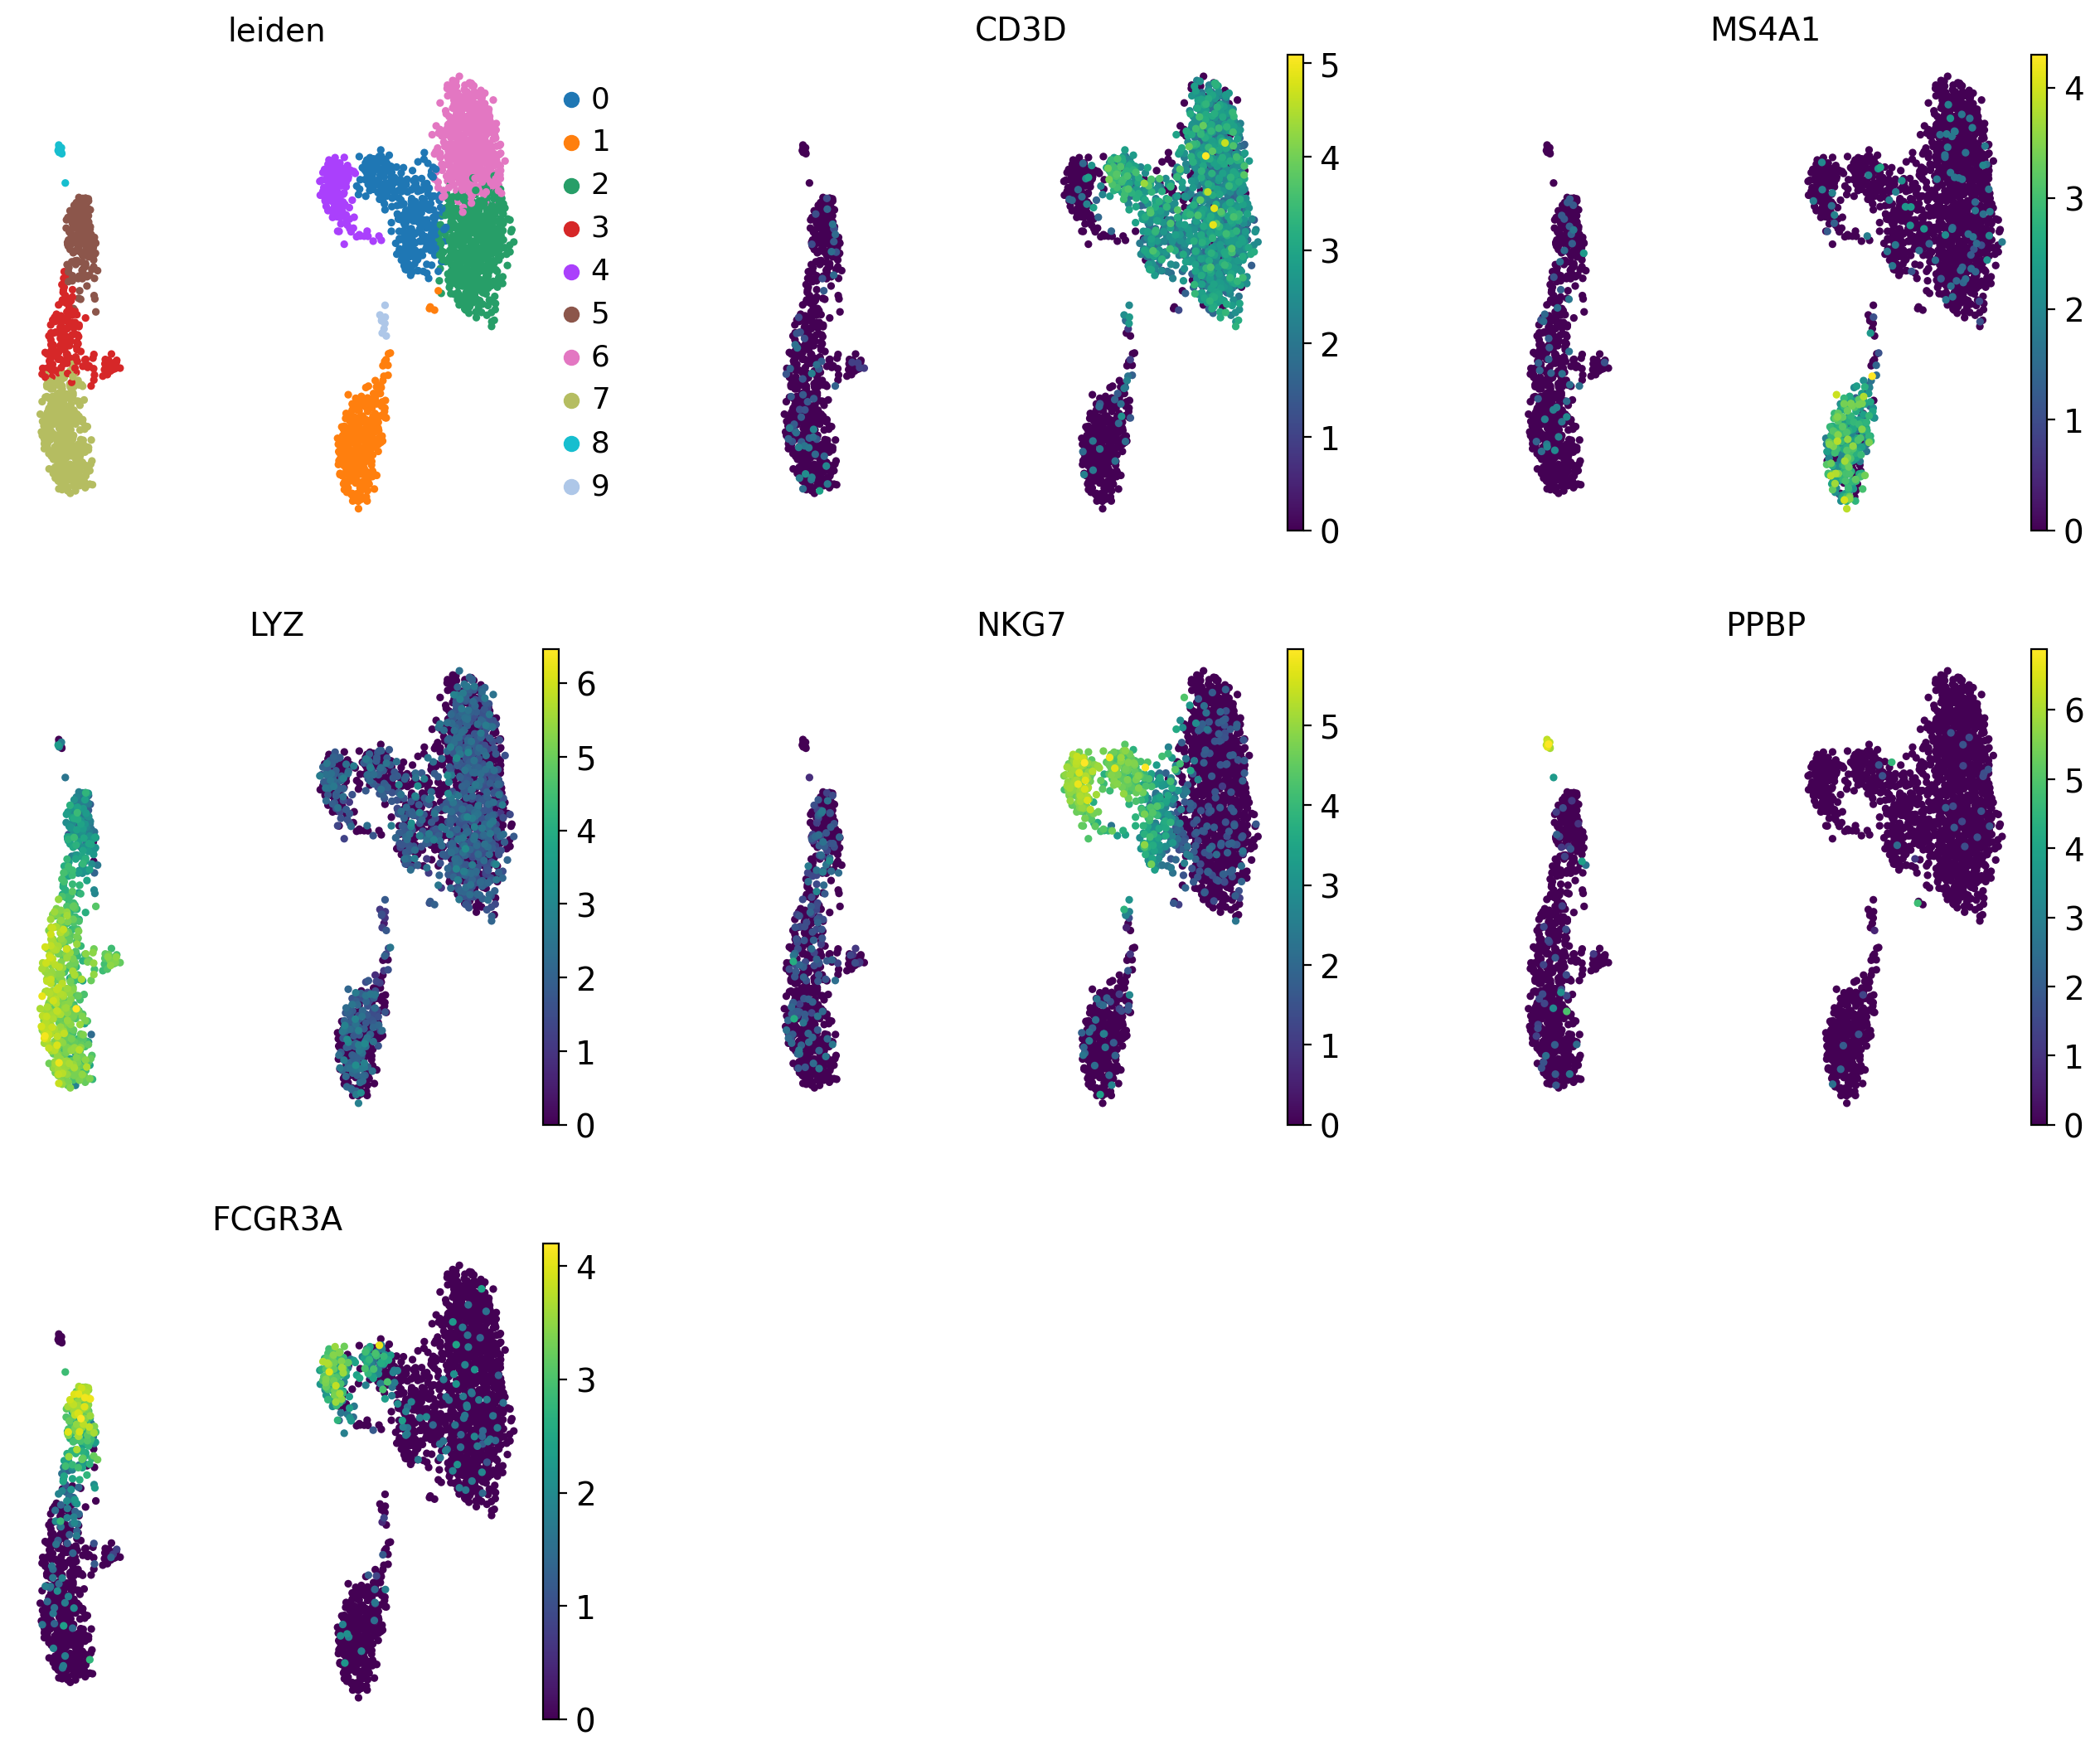

In [5]:
markers = [g for g in ["CD3D", "MS4A1", "LYZ", "NKG7", "PPBP", "FCGR3A"] if g in adata.var_names]
sc.pl.umap(adata, color=["leiden", *markers], ncols=3, wspace=0.3)


Lineage genes line up with the clusters (T / `CD3D`, B / `MS4A1`,
monocytes / `LYZ`, NK / `NKG7`, platelets / `PPBP`, `FCGR3A` monocytes).

## Other calls

```python
scf.pp.highly_variable_genes(adata, n_top_genes=2000)
scf.pp.highly_variable_genes(adata, n_top_genes=2000, balance_method="none")
scf.pp.highly_variable_genes(adata, marker_genes=["CD3D", "CD8A"])
```

Gold-label comparison: {doc}`pbmc10k_hvg_compare`. Parameters:
{doc}`../user_guide/parameters`.
